# Lorenz63 Trajectory Diagnostics

Load a generated Lorenz63 trajectory and plot the 3D butterfly attractor plus the time series for `x`, `y`, and `z`.

Dataset: `lorenz63_trajectory_10-28-2.7.npz`, where the filename stores `sigma-rho-beta`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

In [2]:
data_file = Path("../data/lorenz63_trajectory_10-28-2.7.npz")
if not data_file.exists():
    data_file = Path("data/lorenz63_trajectory_10-28-2.7.npz")

archive = np.load(data_file)
t = archive["t"].astype(np.float32)
states_np = archive["states"].astype(np.float32) if "states" in archive.files else np.stack(
    [archive["x"], archive["y"], archive["z"]], axis=-1
).astype(np.float32)
print(archive.files)
sigma = float(archive["sigma"])
rho = float(archive["rho"])
beta = float(archive["beta"])
dt = float(np.mean(np.diff(t)))


data = np.load(data_file)
t = data["t"][10000:20000]
x = data["x"][10000:20000]
y = data["y"][10000:20000]
z = data["z"][10000:20000]

print(f"Loaded {data_file}")
print(f"Number of time steps: {len(t)}")
print(f"sigma={sigma}, rho={rho}, beta={beta}")

['t', 'x', 'y', 'z', 'states', 'sigma', 'rho', 'beta']
Loaded ../data/lorenz63_trajectory_10-28-2.7.npz
Number of time steps: 10000
sigma=10.0, rho=28.0, beta=2.7


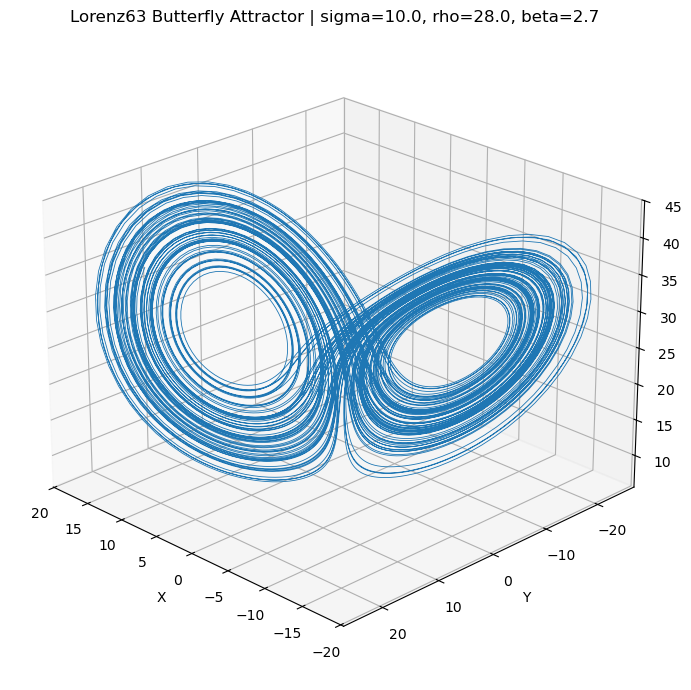

In [3]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot(x, y, z, lw=0.6, color="tab:blue")
ax.set_title(f"Lorenz63 Butterfly Attractor | sigma={sigma}, rho={rho}, beta={beta}")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.view_init(elev=24, azim=135)

plt.tight_layout()
plt.show()

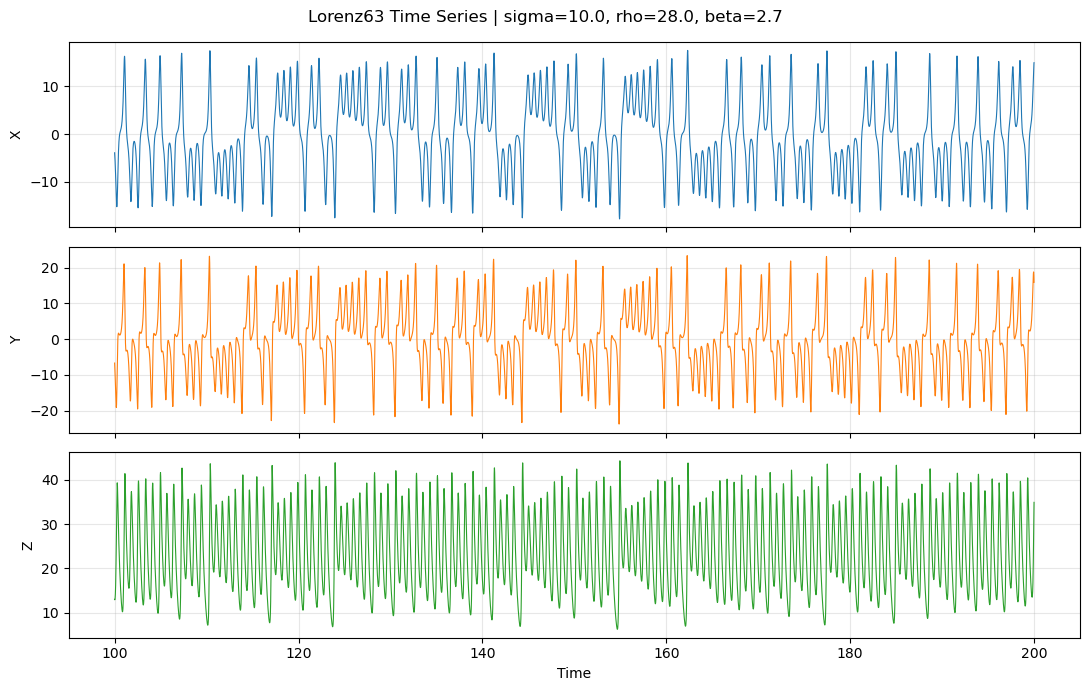

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
fig.suptitle(f"Lorenz63 Time Series | sigma={sigma}, rho={rho}, beta={beta}", y=0.98)

axes[0].plot(t, x, color="tab:blue", lw=0.8)
axes[0].set_ylabel("X")

axes[1].plot(t, y, color="tab:orange", lw=0.8)
axes[1].set_ylabel("Y")

axes[2].plot(t, z, color="tab:green", lw=0.8)
axes[2].set_ylabel("Z")
axes[2].set_xlabel("Time")

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()